# Лабораторная работа №2

Моделирование многоканальной системы массового обслуживания с ожиданием `M/M/n/∞`.
В ноутбуке собраны теоретические расчёты, имитационная модель, сравнение результатов и анализ влияния параметров `n`, `λ` и `μ`.


## Обозначения и параметры

- `λ` — интенсивность входящего потока заявок;
- `μ_eff` — эффективная интенсивность обслуживания одним каналом;
- `n` — число каналов обслуживания;
- `a = λ / μ_eff` — приведённая нагрузка;
- `ρ = λ / (n * μ_eff)` — коэффициент загрузки одного канала.

Условие устойчивости системы `M/M/n/∞`: `λ < n * μ_eff`, то есть `ρ < 1`.


In [1]:
import heapq
from collections import deque
from math import factorial
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import Rectangle
from IPython.display import display

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

BASE_SEED = 42
lam = 10.0
n_channels = 4
simulation_time = 3000.0
replications = 12
mu_rpc = 30.0
mu_resp = 40.0
database_size = 1000
command_types = ['GET', 'SET', 'DELETE']
command_probabilities = np.array([0.8, 0.15, 0.05])

def generate_execution_time(command: str, db_size: int, rng: np.random.Generator) -> float:
    means = {"GET": np.log(db_size) * 0.020, "DELETE": np.log(db_size) * 0.024, "SET": db_size * 0.00020}
    return float(rng.exponential(means[command]))

def sample_service_time(mu_rpc: float, mu_resp: float, db_size: int, rng: np.random.Generator, service_rate_scale: float = 1.0):
    command = rng.choice(command_types, p=command_probabilities)
    rpc_time = rng.exponential(1.0 / mu_rpc)
    exec_time = generate_execution_time(command, db_size, rng)
    resp_time = rng.exponential(1.0 / mu_resp)
    scale = max(service_rate_scale, 1e-9)
    rpc_time /= scale
    exec_time /= scale
    resp_time /= scale
    return float(rpc_time + exec_time + resp_time), {"command": command, "rpc_time": float(rpc_time), "exec_time": float(exec_time), "resp_time": float(resp_time)}

def estimate_mean_service_time(mu_rpc: float, mu_resp: float, db_size: int, samples: int = 50000, seed: int = BASE_SEED, service_rate_scale: float = 1.0) -> float:
    rng = np.random.default_rng(seed)
    values = [sample_service_time(mu_rpc, mu_resp, db_size, rng, service_rate_scale)[0] for _ in range(samples)]
    return float(np.mean(values))

def erlang_c_probability(lam: float, mu: float, n: int):
    offered_load = lam / mu
    utilization = lam / (n * mu)
    if utilization >= 1:
        return 1.0, 0.0
    sum_terms = sum((offered_load ** k) / factorial(k) for k in range(n))
    tail = (offered_load ** n) / (factorial(n) * (1.0 - utilization))
    p0 = 1.0 / (sum_terms + tail)
    return float(tail * p0), float(p0)

def theoretical_characteristics(lam: float, mu: float, n: int):
    offered_load = lam / mu
    utilization = lam / (n * mu)
    p_wait, p0 = erlang_c_probability(lam, mu, n)
    if utilization >= 1:
        return {"p0": 0.0, "p_wait": 1.0, "L_q": float("inf"), "L": float("inf"), "W_q": float("inf"), "W": float("inf"), "mean_busy_channels": offered_load, "utilization": utilization, "offered_load": offered_load, "is_stable": False}
    l_q = p_wait * utilization / (1.0 - utilization)
    w_q = l_q / lam
    w = w_q + 1.0 / mu
    return {"p0": p0, "p_wait": p_wait, "L_q": l_q, "L": lam * w, "W_q": w_q, "W": w, "mean_busy_channels": offered_load, "utilization": utilization, "offered_load": offered_load, "is_stable": True}

def simulate_mm_n_infinity(lam: float, mu_rpc: float, mu_resp: float, n_channels: int, simulation_time: float, db_size: int, seed: int, service_rate_scale: float = 1.0, track_requests: bool = False):
    rng = np.random.default_rng(seed)
    next_arrival = rng.exponential(1.0 / lam)
    servers = [{"channel": idx, "busy": False, "finish_time": float("inf")} for idx in range(n_channels)]
    event_heap = []
    queue = deque()
    requests_info = []
    arrived = served = waited = request_id = 0
    wait_times, service_times, system_times = [], [], []
    area_queue = area_system = area_busy = idle_time = 0.0
    last_event_time = 0.0

    def free_server_idx():
        for idx, server in enumerate(servers):
            if not server["busy"]:
                return idx
        return None

    def start_service(arrival_time, start_time, server_idx, request_meta):
        nonlocal served, waited
        service_time, phases = sample_service_time(mu_rpc, mu_resp, db_size, rng, service_rate_scale)
        finish_time = start_time + service_time
        servers[server_idx]["busy"] = True
        servers[server_idx]["finish_time"] = finish_time
        heapq.heappush(event_heap, (finish_time, server_idx))
        wait_time = start_time - arrival_time
        if wait_time > 1e-12:
            waited += 1
        served += 1
        wait_times.append(float(wait_time))
        service_times.append(float(service_time))
        system_times.append(float(wait_time + service_time))
        if track_requests:
            request_meta.update({"start_time": float(start_time), "end_time": float(finish_time), "wait_time": float(wait_time), "service_time": float(service_time), "channel": servers[server_idx]["channel"], **phases})
            requests_info.append(request_meta)

    while True:
        next_departure = event_heap[0][0] if event_heap else float("inf")
        event_time = min(next_arrival, next_departure)
        if event_time == float("inf"):
            break
        capped = min(event_time, simulation_time)
        if capped > last_event_time:
            dt = capped - last_event_time
            busy_servers = sum(1 for server in servers if server["busy"])
            queue_len = len(queue)
            area_queue += queue_len * dt
            area_system += (queue_len + busy_servers) * dt
            area_busy += busy_servers * dt
            if busy_servers == 0:
                idle_time += dt
            last_event_time = capped
        if event_time > simulation_time:
            break
        if next_arrival <= next_departure:
            arrived += 1
            request_id += 1
            request_meta = {"id": request_id, "arrival_time": float(event_time), "status": "served"}
            idx = free_server_idx()
            if idx is not None:
                start_service(event_time, event_time, idx, request_meta)
            else:
                queue.append((event_time, request_meta))
            next_arrival = event_time + rng.exponential(1.0 / lam)
        else:
            finish_time, idx = heapq.heappop(event_heap)
            if abs(servers[idx]["finish_time"] - finish_time) > 1e-12:
                continue
            if queue:
                arrival_time, request_meta = queue.popleft()
                start_service(arrival_time, event_time, idx, request_meta)
            else:
                servers[idx]["busy"] = False
                servers[idx]["finish_time"] = float("inf")

    return {"arrived": arrived, "served": served, "waited_requests": waited, "p_wait": waited / arrived if arrived else 0.0, "p0": idle_time / simulation_time if simulation_time else 0.0, "mean_wait_time": float(np.mean(wait_times)) if wait_times else 0.0, "mean_service_time": float(np.mean(service_times)) if service_times else 0.0, "mean_system_time": float(np.mean(system_times)) if system_times else 0.0, "mean_queue_length": area_queue / simulation_time, "mean_system_size": area_system / simulation_time, "mean_busy_channels": area_busy / simulation_time, "utilization": area_busy / (n_channels * simulation_time), "wait_times": wait_times, "service_times": service_times, "system_times": system_times, "requests_info": requests_info}

def aggregate_replications(lam: float, mu_rpc: float, mu_resp: float, n_channels: int, simulation_time: float, db_size: int, replications: int, base_seed: int = BASE_SEED, service_rate_scale: float = 1.0):
    runs = [simulate_mm_n_infinity(lam, mu_rpc, mu_resp, n_channels, simulation_time, db_size, base_seed + idx, service_rate_scale) for idx in range(replications)]
    metrics = ["p0", "p_wait", "mean_wait_time", "mean_service_time", "mean_system_time", "mean_queue_length", "mean_system_size", "mean_busy_channels", "utilization"]
    result = {"replications": replications}
    for metric in metrics:
        values = np.array([run[metric] for run in runs], dtype=float)
        result[metric] = float(values.mean())
        result[f"{metric}_std"] = float(values.std(ddof=1)) if len(values) > 1 else 0.0
    return result


## Базовое сравнение теории и имитации


In [2]:
mean_service_time = estimate_mean_service_time(mu_rpc, mu_resp, database_size)
mu_eff = 1.0 / mean_service_time
base_theory = theoretical_characteristics(lam, mu_eff, n_channels)
base_simulation = aggregate_replications(lam, mu_rpc, mu_resp, n_channels, simulation_time, database_size, replications)

base_parameters = pd.DataFrame({
    "Параметр": ["λ", "n", "μ_rpc", "μ_resp", "Размер БД", "Оценка E[S]", "Оценка μ_eff", "Приведённая нагрузка a = λ/μ_eff", "Загрузка канала ρ = λ/(nμ_eff)"],
    "Значение": [lam, n_channels, mu_rpc, mu_resp, database_size, mean_service_time, mu_eff, base_theory["offered_load"], base_theory["utilization"]],
})
comparison = pd.DataFrame({
    "Характеристика": ["P0", "P_wait", "L_q", "L", "W_q", "W", "Среднее число занятых каналов", "Коэффициент загрузки ρ"],
    "Симуляция": [base_simulation["p0"], base_simulation["p_wait"], base_simulation["mean_queue_length"], base_simulation["mean_system_size"], base_simulation["mean_wait_time"], base_simulation["mean_system_time"], base_simulation["mean_busy_channels"], base_simulation["utilization"]],
    "Теория": [base_theory["p0"], base_theory["p_wait"], base_theory["L_q"], base_theory["L"], base_theory["W_q"], base_theory["W"], base_theory["mean_busy_channels"], base_theory["utilization"]],
})
comparison["Абс. отклонение"] = (comparison["Симуляция"] - comparison["Теория"]).abs()
display(base_parameters)
comparison


,Параметр,Значение
0,λ,10.000000
1,n,4.000000
2,μ_rpc,30.000000
3,μ_resp,40.000000
4,Размер БД,1000.000000
5,Оценка E[S],0.207473
6,Оценка μ_eff,4.819904
7,Приведённая нагрузка a = λ/μ_eff,2.074730
8,Загрузка канала ρ = λ/(nμ_eff),0.518683


,Характеристика,Симуляция,Теория,Абс. отклонение
0,P0,0.120027,0.120201,0.000173
1,P_wait,0.188974,0.192801,0.003827
2,L_q,0.162439,0.207769,0.045329
3,L,2.234519,2.282499,0.047980
4,W_q,0.016230,0.020777,0.004547
5,W,0.223266,0.228250,0.004984
6,Среднее число занятых каналов,2.072080,2.074730,0.002650
7,Коэффициент загрузки ρ,0.518020,0.518683,0.000663


## Влияние количества каналов


In [3]:
rows = []
for current_n in range(1, 9):
    sim_summary = aggregate_replications(lam, mu_rpc, mu_resp, current_n, simulation_time, database_size, replications, BASE_SEED + 100 * current_n)
    theory_summary = theoretical_characteristics(lam, mu_eff, current_n)
    rows.append({"n": current_n, "sim_Wq": sim_summary["mean_wait_time"], "theory_Wq": theory_summary["W_q"], "sim_Lq": sim_summary["mean_queue_length"], "theory_Lq": theory_summary["L_q"], "sim_W": sim_summary["mean_system_time"], "theory_W": theory_summary["W"], "sim_utilization": sim_summary["utilization"], "theory_utilization": theory_summary["utilization"]})
channel_results = pd.DataFrame(rows)
channel_results


,n,sim_Wq,theory_Wq,sim_Lq,theory_Lq,sim_W,theory_W,sim_utilization,theory_utilization
0,1,773.307080,inf,7709.581628,inf,773.514906,inf,0.999951,2.074730
1,2,49.932688,inf,500.766696,inf,50.139691,inf,0.998859,1.037365
2,3,0.085540,0.107643,0.853689,1.076429,0.293289,0.315116,0.691034,0.691577
3,4,0.016513,0.020777,0.164871,0.207769,0.223802,0.228250,0.517271,0.518683
4,5,0.004015,0.004833,0.040303,0.048333,0.211221,0.212306,0.415826,0.414946
5,6,0.000935,0.001122,0.009383,0.011219,0.207747,0.208595,0.345872,0.345788
6,7,0.000206,0.000247,0.002057,0.002468,0.207009,0.207720,0.295569,0.296390
7,8,0.000048,0.000051,0.000479,0.000506,0.207599,0.207524,0.259342,0.259341


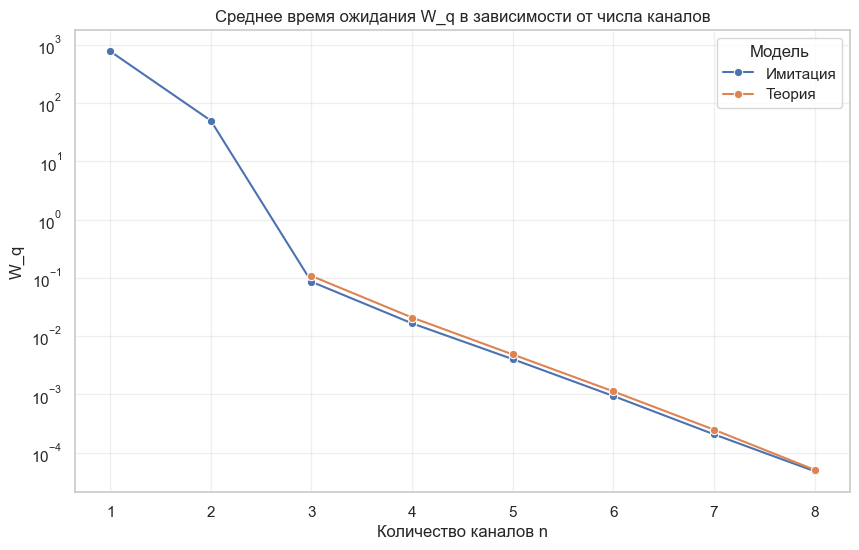

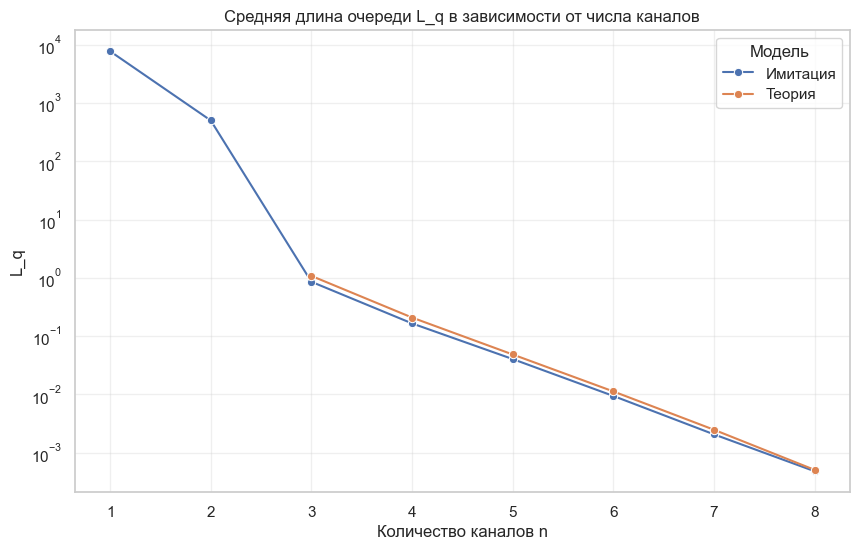

In [4]:
wait_by_n = channel_results.melt(id_vars="n", value_vars=["sim_Wq", "theory_Wq"], var_name="Модель", value_name="W_q")
wait_by_n["Модель"] = wait_by_n["Модель"].map({"sim_Wq": "Имитация", "theory_Wq": "Теория"})
plt.figure()
sns.lineplot(data=wait_by_n, x="n", y="W_q", hue="Модель", marker="o")
plt.title("Среднее время ожидания W_q в зависимости от числа каналов")
plt.xlabel("Количество каналов n")
plt.ylabel("W_q")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()

queue_by_n = channel_results.melt(id_vars="n", value_vars=["sim_Lq", "theory_Lq"], var_name="Модель", value_name="L_q")
queue_by_n["Модель"] = queue_by_n["Модель"].map({"sim_Lq": "Имитация", "theory_Lq": "Теория"})
plt.figure()
sns.lineplot(data=queue_by_n, x="n", y="L_q", hue="Модель", marker="o")
plt.title("Средняя длина очереди L_q в зависимости от числа каналов")
plt.xlabel("Количество каналов n")
plt.ylabel("L_q")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.show()


## Влияние интенсивности входящего потока


In [5]:
rows = []
for current_lambda in np.linspace(4.0, 18.0, 8):
    sim_summary = aggregate_replications(float(current_lambda), mu_rpc, mu_resp, n_channels, simulation_time, database_size, replications, BASE_SEED + int(current_lambda * 100))
    theory_summary = theoretical_characteristics(float(current_lambda), mu_eff, n_channels)
    rows.append({"lambda": float(current_lambda), "sim_Wq": sim_summary["mean_wait_time"], "theory_Wq": theory_summary["W_q"], "sim_Lq": sim_summary["mean_queue_length"], "theory_Lq": theory_summary["L_q"], "sim_utilization": sim_summary["utilization"], "theory_utilization": theory_summary["utilization"]})
lambda_results = pd.DataFrame(rows)
lambda_results


,lambda,sim_Wq,theory_Wq,sim_Lq,theory_Lq,sim_utilization,theory_utilization
0,4.0,0.000615,0.000711,0.002450,0.002845,0.206551,0.207473
1,6.0,0.002639,0.003138,0.015915,0.018825,0.311916,0.311210
2,8.0,0.007430,0.008974,0.059381,0.071791,0.413939,0.414946
3,10.0,0.016798,0.020777,0.168150,0.207769,0.518429,0.518683
4,12.0,0.034997,0.043462,0.419760,0.521546,0.621624,0.622419
5,14.0,0.071715,0.089043,1.005644,1.246608,0.727383,0.726156
6,16.0,0.151322,0.198583,2.416549,3.177331,0.826063,0.829892
7,18.0,0.531184,0.669671,9.567791,12.054069,0.932786,0.933629


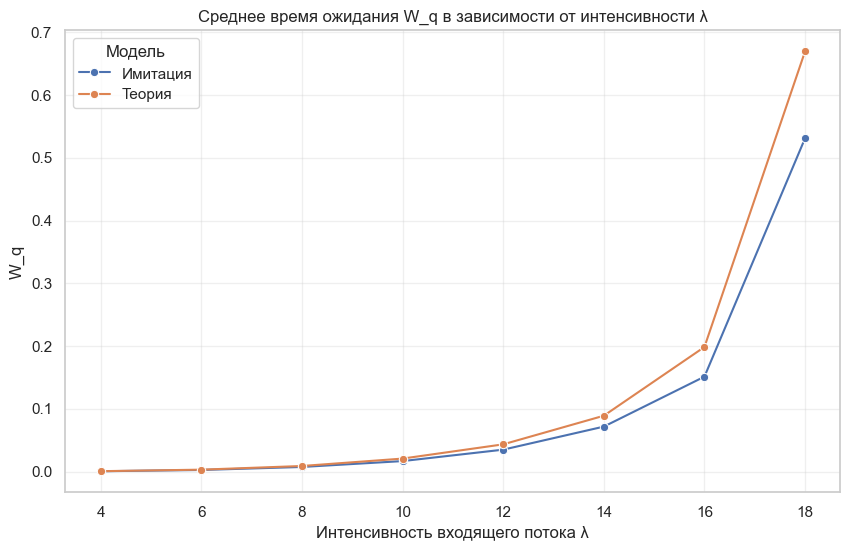

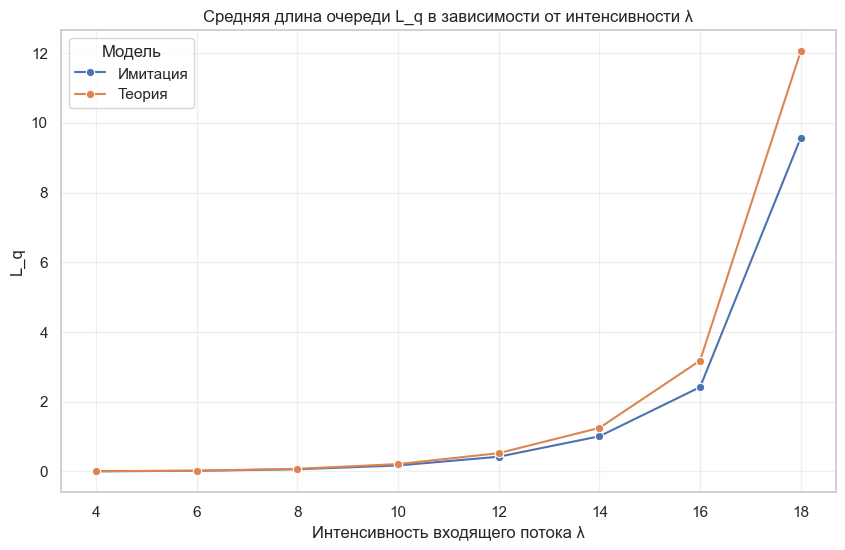

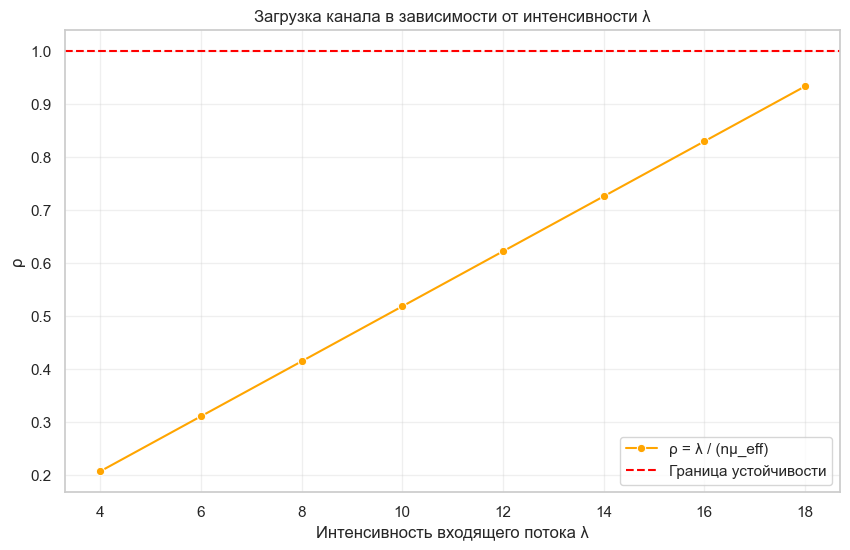

In [6]:
lambda_wait = lambda_results.melt(id_vars="lambda", value_vars=["sim_Wq", "theory_Wq"], var_name="Модель", value_name="W_q")
lambda_wait["Модель"] = lambda_wait["Модель"].map({"sim_Wq": "Имитация", "theory_Wq": "Теория"})
plt.figure()
sns.lineplot(data=lambda_wait, x="lambda", y="W_q", hue="Модель", marker="o")
plt.title("Среднее время ожидания W_q в зависимости от интенсивности λ")
plt.xlabel("Интенсивность входящего потока λ")
plt.ylabel("W_q")
plt.grid(True, alpha=0.3)
plt.show()

lambda_queue = lambda_results.melt(id_vars="lambda", value_vars=["sim_Lq", "theory_Lq"], var_name="Модель", value_name="L_q")
lambda_queue["Модель"] = lambda_queue["Модель"].map({"sim_Lq": "Имитация", "theory_Lq": "Теория"})
plt.figure()
sns.lineplot(data=lambda_queue, x="lambda", y="L_q", hue="Модель", marker="o")
plt.title("Средняя длина очереди L_q в зависимости от интенсивности λ")
plt.xlabel("Интенсивность входящего потока λ")
plt.ylabel("L_q")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
sns.lineplot(data=lambda_results, x="lambda", y="theory_utilization", marker="o", color="orange", label="ρ = λ / (nμ_eff)")
plt.axhline(1.0, color="red", linestyle="--", label="Граница устойчивости")
plt.title("Загрузка канала в зависимости от интенсивности λ")
plt.xlabel("Интенсивность входящего потока λ")
plt.ylabel("ρ")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


## Влияние интенсивности обслуживания


In [7]:
rows = []
for idx, scale in enumerate([0.75, 0.90, 1.00, 1.10, 1.25, 1.50]):
    current_mean_service = estimate_mean_service_time(mu_rpc, mu_resp, database_size, seed=BASE_SEED + 2000 + idx, service_rate_scale=float(scale))
    current_mu_eff = 1.0 / current_mean_service
    sim_summary = aggregate_replications(lam, mu_rpc, mu_resp, n_channels, simulation_time, database_size, replications, BASE_SEED + 500 * idx, service_rate_scale=float(scale))
    theory_summary = theoretical_characteristics(lam, current_mu_eff, n_channels)
    rows.append({"mu_eff": current_mu_eff, "service_rate_scale": float(scale), "sim_Wq": sim_summary["mean_wait_time"], "theory_Wq": theory_summary["W_q"], "sim_Lq": sim_summary["mean_queue_length"], "theory_Lq": theory_summary["L_q"], "sim_utilization": sim_summary["utilization"], "theory_utilization": theory_summary["utilization"]})
mu_results = pd.DataFrame(rows).sort_values("mu_eff").reset_index(drop=True)
mu_results


,mu_eff,service_rate_scale,sim_Wq,theory_Wq,sim_Lq,theory_Lq,sim_utilization,theory_utilization
0,3.600731,0.75,0.073698,0.095359,0.737935,0.953594,0.690987,0.694303
1,4.345919,0.90,0.028642,0.034714,0.287116,0.347141,0.577254,0.575252
2,4.829344,1.00,0.016798,0.020580,0.168150,0.205798,0.518429,0.517669
3,5.312746,1.10,0.010528,0.013002,0.105233,0.130020,0.471244,0.470566
4,6.052766,1.25,0.005830,0.007025,0.058368,0.070254,0.414428,0.413034
5,7.246354,1.50,0.002610,0.003037,0.026166,0.030373,0.346459,0.345001


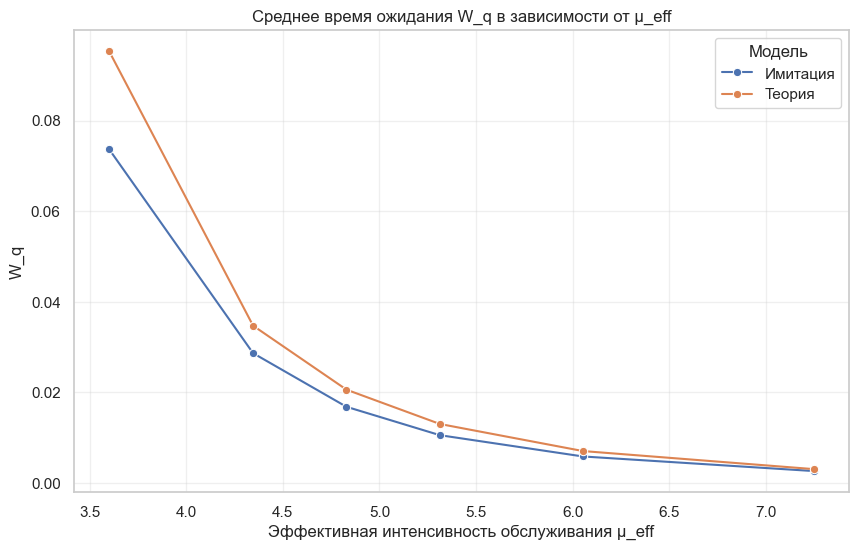

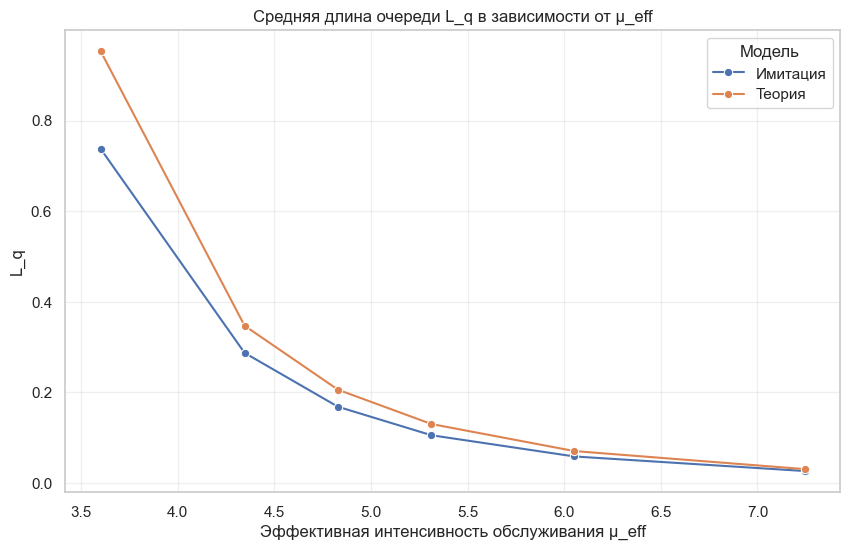

In [8]:
mu_wait = mu_results.melt(id_vars="mu_eff", value_vars=["sim_Wq", "theory_Wq"], var_name="Модель", value_name="W_q")
mu_wait["Модель"] = mu_wait["Модель"].map({"sim_Wq": "Имитация", "theory_Wq": "Теория"})
plt.figure()
sns.lineplot(data=mu_wait, x="mu_eff", y="W_q", hue="Модель", marker="o")
plt.title("Среднее время ожидания W_q в зависимости от μ_eff")
plt.xlabel("Эффективная интенсивность обслуживания μ_eff")
plt.ylabel("W_q")
plt.grid(True, alpha=0.3)
plt.show()

mu_queue = mu_results.melt(id_vars="mu_eff", value_vars=["sim_Lq", "theory_Lq"], var_name="Модель", value_name="L_q")
mu_queue["Модель"] = mu_queue["Модель"].map({"sim_Lq": "Имитация", "theory_Lq": "Теория"})
plt.figure()
sns.lineplot(data=mu_queue, x="mu_eff", y="L_q", hue="Модель", marker="o")
plt.title("Средняя длина очереди L_q в зависимости от μ_eff")
plt.xlabel("Эффективная интенсивность обслуживания μ_eff")
plt.ylabel("L_q")
plt.grid(True, alpha=0.3)
plt.show()


## Распределения и временная диаграмма


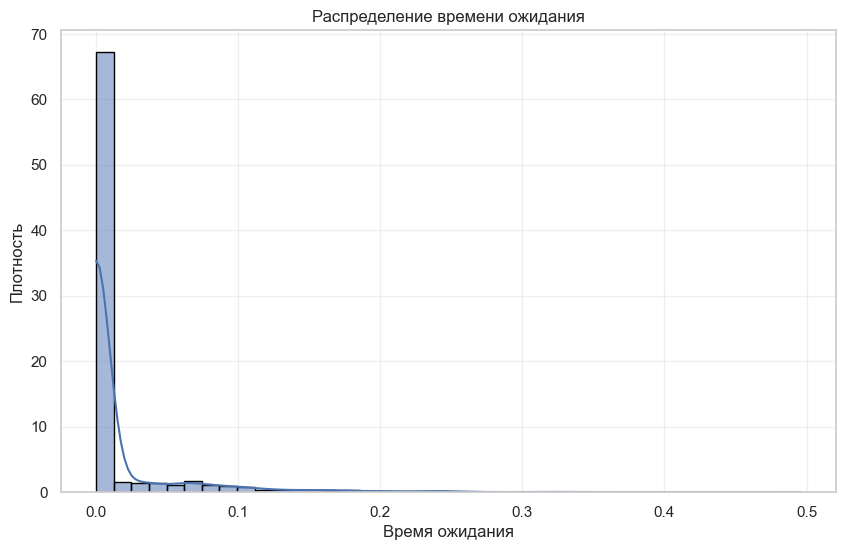

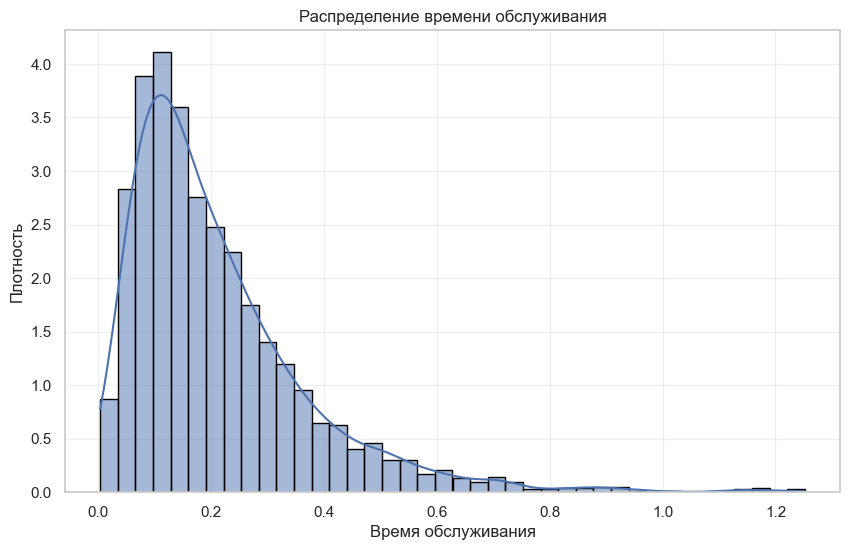

In [9]:
detailed_run = simulate_mm_n_infinity(lam, mu_rpc, mu_resp, n_channels, 250.0, database_size, BASE_SEED + 999, track_requests=True)
plt.figure()
sns.histplot(detailed_run["wait_times"], bins=40, kde=True, stat="density", edgecolor="black")
plt.title("Распределение времени ожидания")
plt.xlabel("Время ожидания")
plt.ylabel("Плотность")
plt.grid(True, alpha=0.3)
plt.show()

plt.figure()
sns.histplot(detailed_run["service_times"], bins=40, kde=True, stat="density", edgecolor="black")
plt.title("Распределение времени обслуживания")
plt.xlabel("Время обслуживания")
plt.ylabel("Плотность")
plt.grid(True, alpha=0.3)
plt.show()


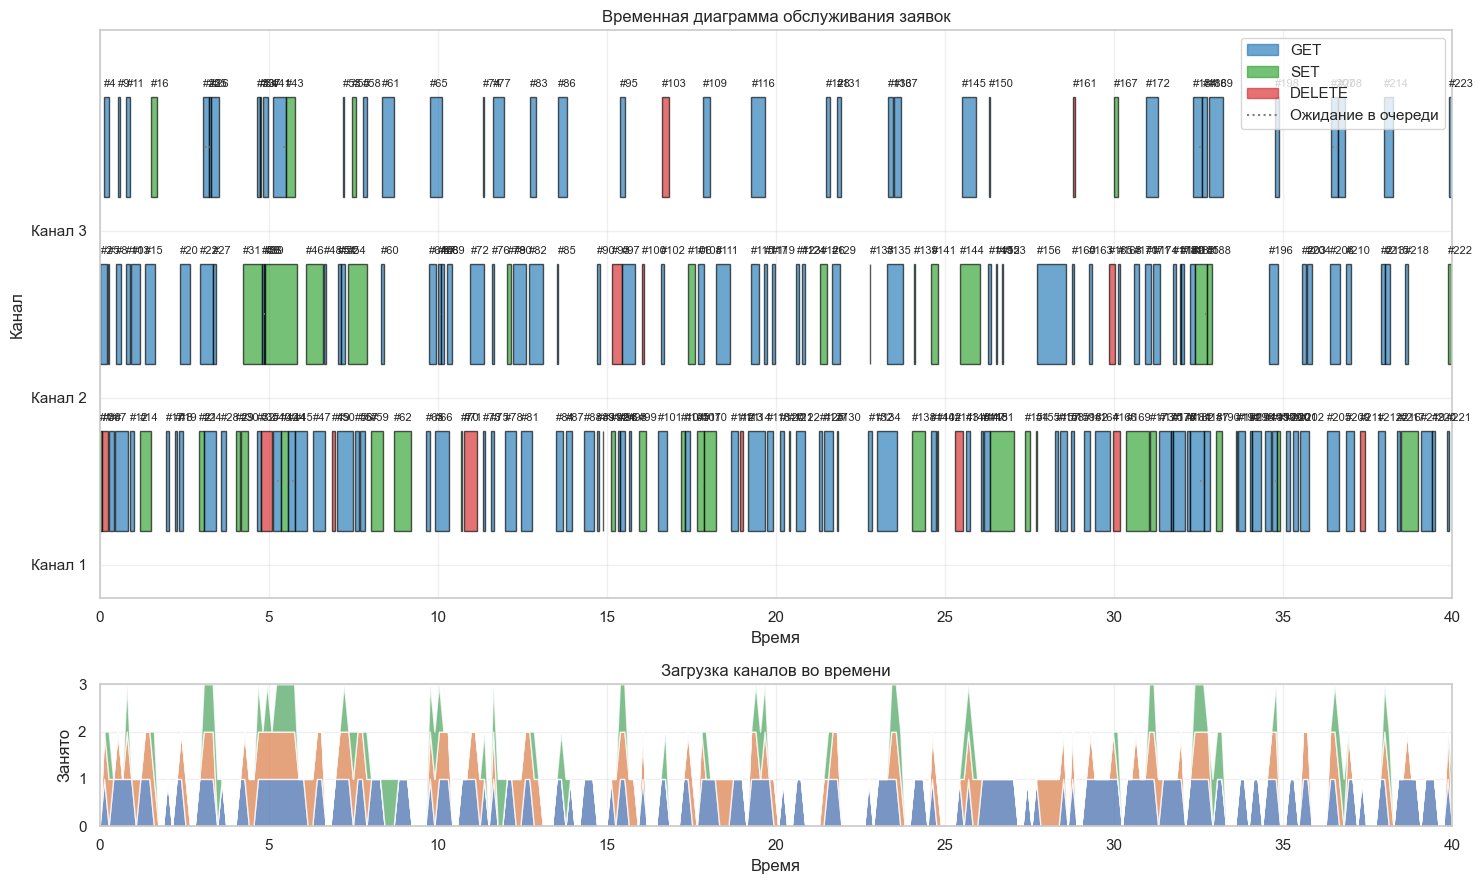

In [10]:
def plot_timeline_mm_n(result: dict, horizon: float, n_channels: int):
    requests_info = [req for req in result["requests_info"] if req["arrival_time"] <= horizon]
    colors = {"GET": "#1f77b4", "SET": "#2ca02c", "DELETE": "#d62728"}
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(15, 9), gridspec_kw={"height_ratios": [4, 1]})
    channel_requests = {i: [] for i in range(n_channels)}
    for req in requests_info:
        channel_requests[req["channel"]].append(req)
    for channel in range(n_channels):
        for req in channel_requests[channel]:
            if req["start_time"] > horizon:
                continue
            visible_end = min(req["end_time"], horizon)
            rect = Rectangle((req["start_time"], channel + 0.2), visible_end - req["start_time"], 0.6, facecolor=colors[req["command"]], edgecolor="black", alpha=0.65)
            ax1.add_patch(rect)
            ax1.text(req["start_time"], channel + 0.85, f"#{req['id']}", fontsize=8, ha="left", va="bottom")
            if req["wait_time"] > 0:
                ax1.plot([req["arrival_time"], req["start_time"]], [channel + 0.5, channel + 0.5], color="gray", linestyle=":", linewidth=1.2)
    ax1.set_xlim(0, horizon)
    ax1.set_ylim(-0.2, n_channels + 0.2)
    ax1.set_yticks(range(n_channels))
    ax1.set_yticklabels([f"Канал {idx + 1}" for idx in range(n_channels)])
    ax1.set_xlabel("Время")
    ax1.set_ylabel("Канал")
    ax1.set_title("Временная диаграмма обслуживания заявок")
    ax1.grid(True, alpha=0.3)
    legend_handles = [mpatches.Patch(color=color, label=label, alpha=0.65) for label, color in colors.items()]
    legend_handles.append(plt.Line2D([0], [0], color="gray", linestyle=":", label="Ожидание в очереди"))
    ax1.legend(handles=legend_handles, loc="upper right")
    time_grid = np.linspace(0, horizon, 300)
    channel_loads = [[] for _ in range(n_channels)]
    for t in time_grid:
        for channel in range(n_channels):
            busy = any(req["start_time"] <= t <= req["end_time"] for req in channel_requests[channel])
            channel_loads[channel].append(1 if busy else 0)
    ax2.stackplot(time_grid, channel_loads, labels=[f"Канал {idx + 1}" for idx in range(n_channels)], alpha=0.75)
    ax2.set_xlim(0, horizon)
    ax2.set_ylim(0, n_channels)
    ax2.set_xlabel("Время")
    ax2.set_ylabel("Занято")
    ax2.set_title("Загрузка каналов во времени")
    ax2.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

timeline_run = simulate_mm_n_infinity(5.0, mu_rpc, mu_resp, 3, 40.0, database_size, BASE_SEED + 2024, track_requests=True)
plot_timeline_mm_n(timeline_run, 40.0, 3)


## Контрольные сценарии


In [11]:
scenario_rows = []
scenarios = [
    ("Высокая нагрузка, мало каналов", 10.0, 2, 1.0),
    ("Базовый режим", 10.0, 4, 1.0),
    ("Больше каналов", 10.0, 6, 1.0),
    ("Быстрое обслуживание", 10.0, 4, 1.30),
    ("Почти граница устойчивости", 18.5, 4, 1.0),
]
for idx, (label, current_lambda, current_n, current_scale) in enumerate(scenarios):
    current_mean_service = estimate_mean_service_time(mu_rpc, mu_resp, database_size, seed=BASE_SEED + 7000 + idx, service_rate_scale=current_scale)
    current_mu_eff = 1.0 / current_mean_service
    sim_summary = aggregate_replications(current_lambda, mu_rpc, mu_resp, current_n, simulation_time, database_size, replications, BASE_SEED + 8000 + idx * 100, service_rate_scale=current_scale)
    theory_summary = theoretical_characteristics(current_lambda, current_mu_eff, current_n)
    scenario_rows.append({"Сценарий": label, "λ": current_lambda, "n": current_n, "μ_eff": current_mu_eff, "ρ": theory_summary["utilization"], "W_q (сим.)": sim_summary["mean_wait_time"], "W_q (теор.)": theory_summary["W_q"], "L_q (сим.)": sim_summary["mean_queue_length"], "L_q (теор.)": theory_summary["L_q"]})
scenario_results = pd.DataFrame(scenario_rows)
scenario_results


,Сценарий,λ,n,μ_eff,ρ,W_q (сим.),W_q (теор.),L_q (сим.),L_q (теор.)
0,"Высокая нагрузка, мало каналов",10.0,2,4.848224,1.031305,53.132498,inf,531.183903,inf
1,Базовый режим,10.0,4,4.806973,0.520078,0.016761,0.021051,0.167419,0.210507
2,Больше каналов,10.0,6,4.830040,0.345063,0.000875,0.001108,0.008740,0.011079
3,Быстрое обслуживание,10.0,4,6.291920,0.397335,0.004844,0.005861,0.048441,0.058607
4,Почти граница устойчивости,18.5,4,4.830267,0.957504,0.914044,1.105155,16.930047,20.445376


## Выводы

1. Теоретические значения по формулам Эрланга C и имитационная модель хорошо согласуются по метрикам `P0`, `P_wait`, `L_q`, `W_q`, `W` и средней загрузке каналов.
2. При увеличении числа каналов `n` показатели `W_q` и `L_q` быстро уменьшаются.
3. При росте интенсивности входящего потока `λ` система приближается к границе устойчивости, и очередь растёт ускоренно.
4. Рост эффективной интенсивности обслуживания `μ_eff` снижает загрузку каналов и уменьшает ожидание.
5. Для оптимизации системы полезны два направления: увеличение числа каналов и ускорение обслуживания одной заявки.
